In [4]:
import ast
import pandas as pd
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt
from datasets import load_dataset

datasets = load_dataset('lukebarousse/data_jobs')
df = datasets['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [5]:
df_Ind = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Scientist')].copy()

In [6]:
df_Ind = df_Ind.dropna(subset=['salary_year_avg'])
df_Ind_ex = df_Ind.explode('job_skills')
df_Ind_ex[['salary_year_avg','job_skills']].head()

,salary_year_avg,job_skills
3930,114516.0,python
3930,114516.0,r
3930,114516.0,c++
3930,114516.0,tensorflow
3930,114516.0,tableau


In [7]:
df_Ind_skill = df_Ind_ex.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_Ind_skill = df_Ind_skill.rename(columns={'count':'count_skills', 'median':'median_salary'})

df_total = len(df_Ind)
df_Ind_skill['skill_perc'] = df_Ind_skill['count_skills']/df_total *100
df_skill_demand = df_Ind_skill[df_Ind_skill['skill_perc']>9]
df_skill_demand

,count_skills,median_salary,skill_perc
job_skills,,,
python,64,152500.00,69.565217
sql,49,113500.00,53.260870
r,30,129758.00,32.608696
spark,23,93600.00,25.000000
aws,20,103550.00,21.739130
tableau,19,113500.00,20.652174
tensorflow,16,136008.00,17.391304
azure,15,157500.00,16.304348
hadoop,14,87717.75,15.217391


In [8]:
len(df_skill_demand)

13

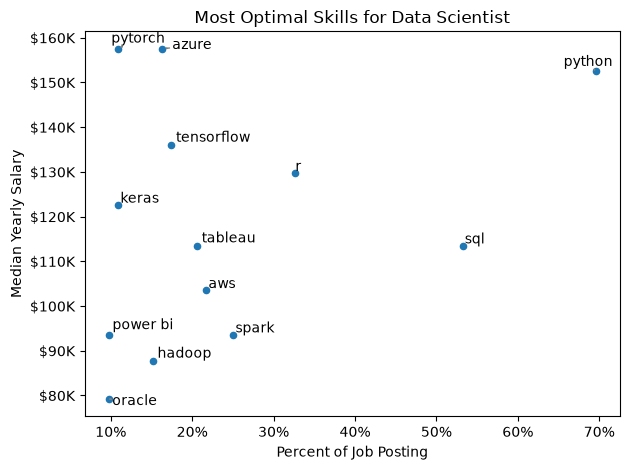

In [19]:
from adjustText import adjust_text

df_skill_demand.plot(kind='scatter', x='skill_perc', y='median_salary')

texts = []
for i, txt in enumerate(df_skill_demand.index):
    texts.append(plt.text(df_skill_demand['skill_perc'].iloc[i], df_skill_demand['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Job Posting')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Scientist')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

In [ ]:
import sys

!{sys.executable} -m pip install adjustText